In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/10001
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  37.59293969068204
RUN  2 , total integrated cost =  33.8574829671503
RUN  3 , total integrated cost =  28.464639783237182
RUN  4 , total integrated cost =  26.044325776318136
RUN  5 , total integrated cost =  22.354898110507197
RUN  6 , total integrated cost =  20.5777848079921
RUN  7 , total integrated cost =  17.659723877512086
RUN  8 , total integrated cost =  16.33301825936177
RUN  9 , total integrated cost =  13.721628270481675
RUN  10 , total integrated cost =  12.412346140555654
RUN  11 , total integrated cost =  10.938483046243105
RUN  12 , total integrated cost =  10.91335636909109
RUN  13 , total integrated cost =  10.88167999484503
RUN  14 , total integrated cost =  10.85138500656702
RUN  15 , total integrated cost =  10.748532639225775
RUN  16

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1962 , total integrated cost =  8.653464659309773
Improved over  1962  iterations in  137.56438129208982  seconds by  99.85339090606945  percent.
Problem in initial value trasfer:  Vmean_exc -62.79057410262651 -62.7893908533989
weight =  6820.859287716994
set cost params:  1.0 0.0 6820.859287716994
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5879.198330319998
Gradient descend method:  None
RUN  1 , total integrated cost =  5814.611932152175
RUN  2 , total integrated cost =  5814.605499660457
RUN  3 , total integrated cost =  5814.605065070712
RUN  4 , total integrated cost =  5814.602335632985
RUN  5 , total integrated cost =  5814.590025559713
RUN  6 , total integrated cost =  5814.587874618544
RUN  7 , total integrated cost =  5814.587430210245
RUN  8 , total integrated cost =  5814.57655768144
RUN  9 , total integrated cost =  5814.554282149306
RUN  10 , total integrated cost =  5814.55288297753
RUN  11 , total integr

ERROR:root:Problem in initial value trasfer


RUN  170 , total integrated cost =  5812.702459123392
Control only changes marginally.
RUN  171 , total integrated cost =  5812.702459123392
Improved over  171  iterations in  10.812372174113989  seconds by  1.131036366874639  percent.
Problem in initial value trasfer:  Vmean_exc -64.75893378354674 -64.76129438792985
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  1 , total integrated cost =  94.91527965421615
RUN  2 , total integrated cost =  83.01400937287231
RUN  3 , total integrated cost =  63.804672049778425
RUN  4 , total integrated cost =  56.792928871047806
RUN  5 , total integrated cost =  48.815947553720356
RUN  6 , total integrated cost =  45.69189320207413
RUN  7 , total integrated cost =  42.078262449157606
RUN  8 , total integrated cost =  40.29219682778734
RUN  9 , total integrated cost =  38.53195217860006
RUN  1

...

RUN  12 , total integrated cost =  14227.665540027227
Control only changes marginally.
RUN  12 , total integrated cost =  14227.665540027227
Improved over  12  iterations in  0.937085336074233  seconds by  1.262232542291713  percent.
Problem in initial value trasfer:  Vmean_exc -63.92199012374573 -63.97378867056179
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10019.968518582271
Gradient descend method:  None
RUN  1 , total integrated cost =  68.04688674581539
RUN  2 , total integrated cost =  57.827053448821225
RUN  3 , total integrated cost =  38.09950472818176
RUN  4 , total integrated cost =  33.118385620541744
RUN  5 , total integrated cost =  26.858802970052597
RUN  6 , total integrated cost =  24.37872585210616
RUN  7 , total integrated cost =  20.78787745465558
RUN  8 , total integrated cost =  20.68464637718094
RUN  9 , total integrated cost =  20.58325737165403
RUN  10 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  475 , total integrated cost =  15.549668719965908
Improved over  475  iterations in  31.656291564926505  seconds by  99.84481319785458  percent.
Problem in initial value trasfer:  Vmean_exc -73.5888416254969 -73.6246721940571
weight =  6443.84693914189
set cost params:  1.0 0.0 6443.84693914189
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10004.62087781965
Gradient descend method:  None
RUN  1 , total integrated cost =  9918.384397757109
RUN  2 , total integrated cost =  9917.888285109018
RUN  3 , total integrated cost =  9917.888038055788
RUN  4 , total integrated cost =  9917.888034386528
RUN  5 , total integrated cost =  9917.888034153872
RUN  6 , total integrated cost =  9917.888034152387
RUN  7 , total integrated cost =  9917.88803415228
RUN  8 , total integrated cost =  9917.888034152276
RUN  9 , total integrated cost =  9917.888034152267


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  9917.888034152267
Control only changes marginally.
RUN  10 , total integrated cost =  9917.888034152267
Improved over  10  iterations in  0.7675299737602472  seconds by  0.8669278399111704  percent.
Problem in initial value trasfer:  Vmean_exc -67.26687592983066 -67.32877876705213


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


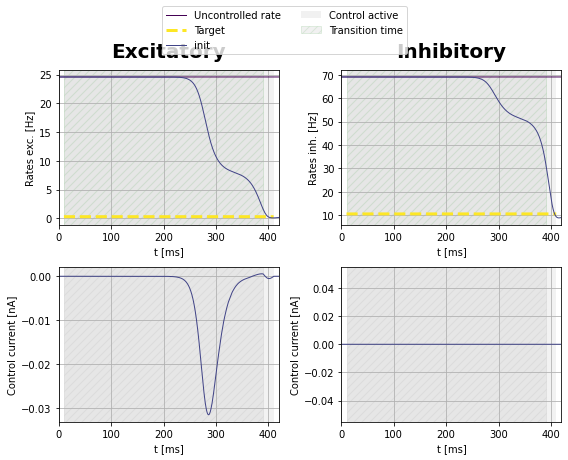

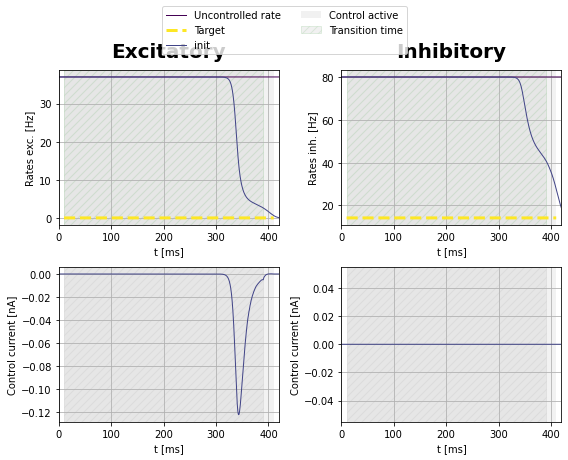

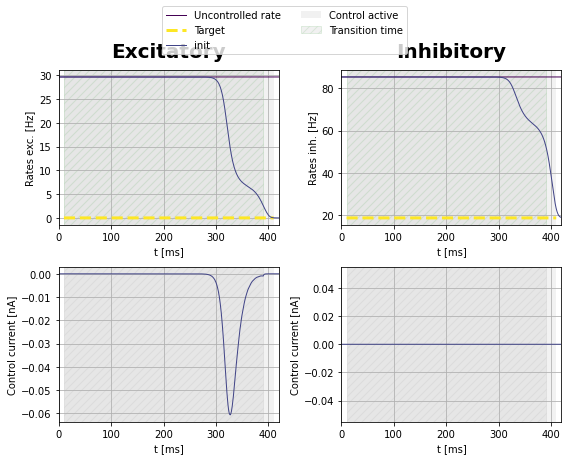

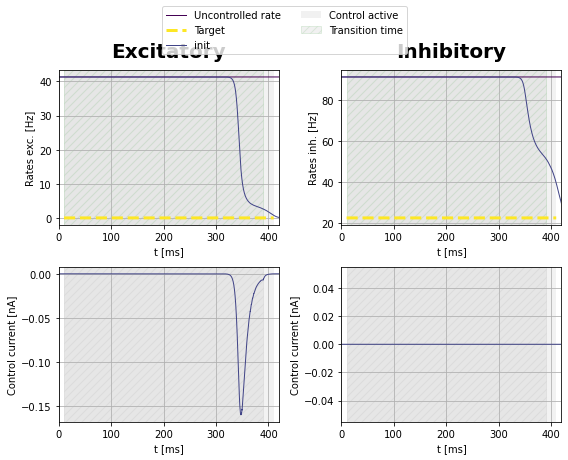

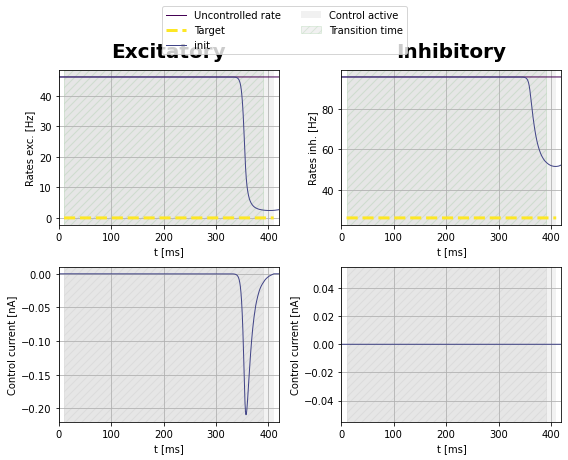

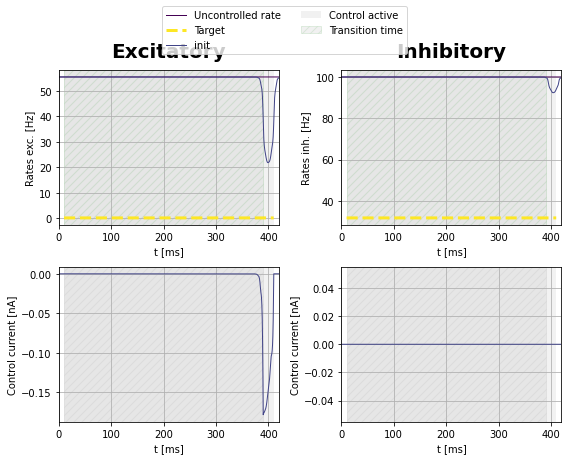

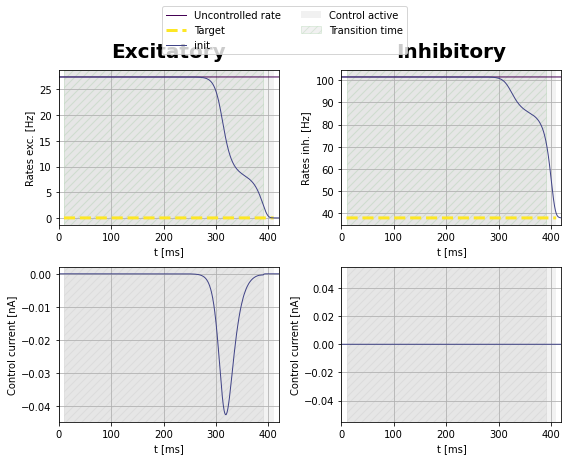

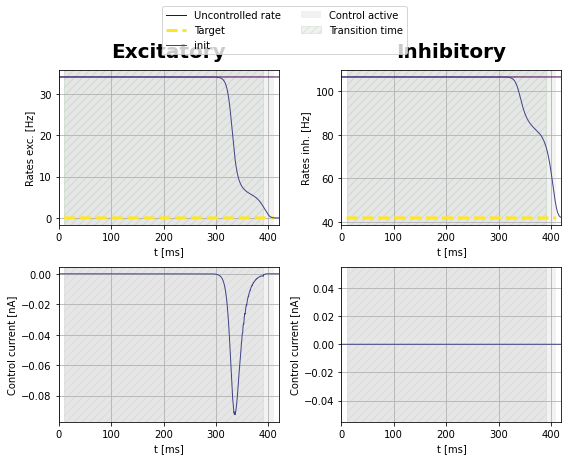

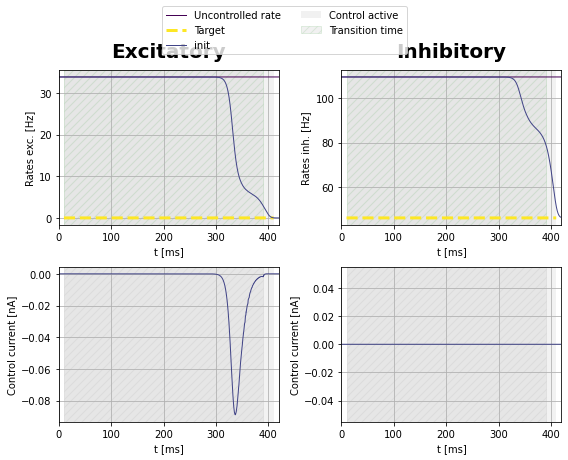

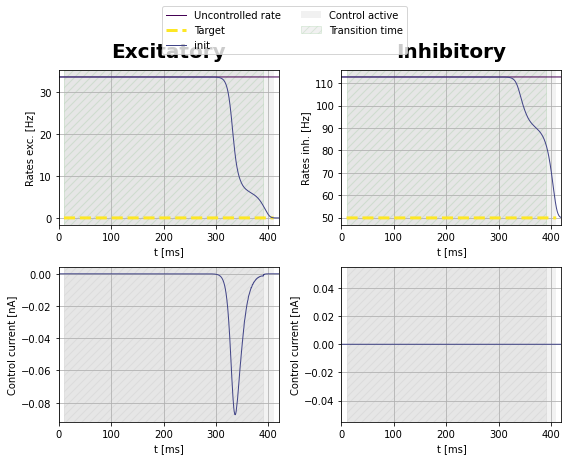

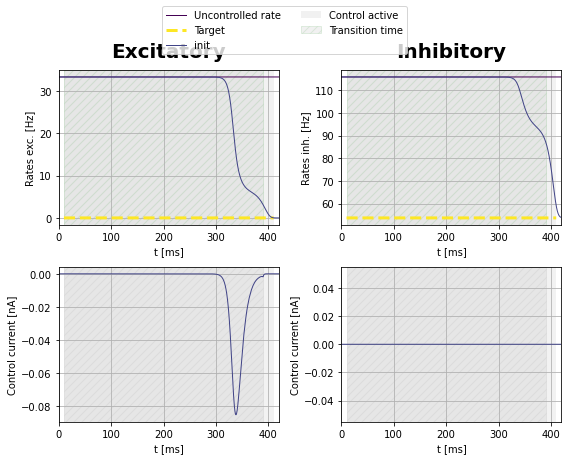

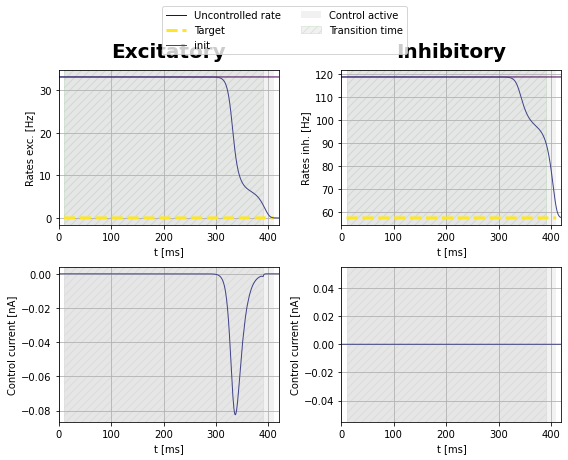

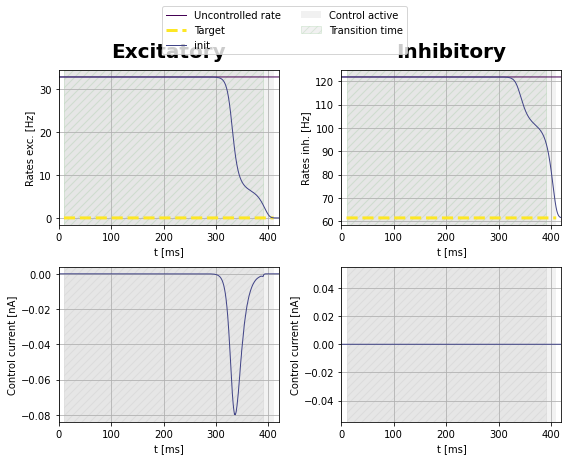

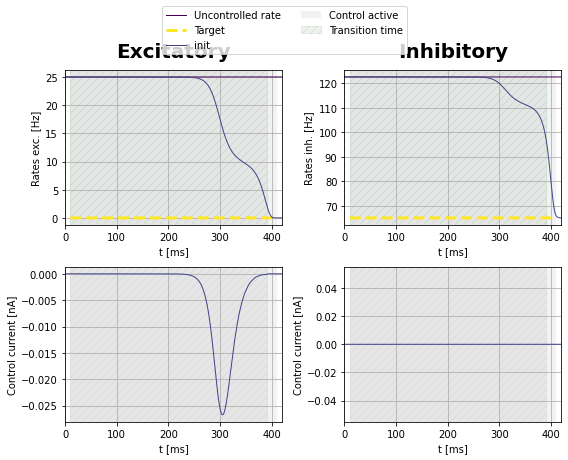

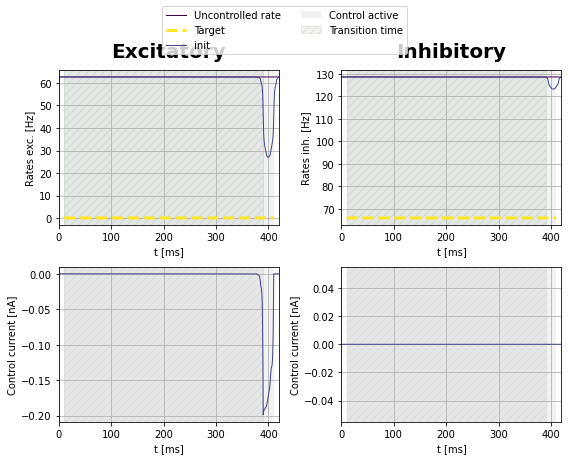

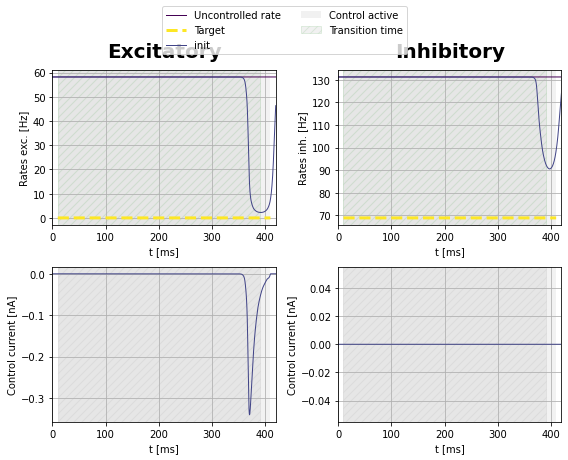

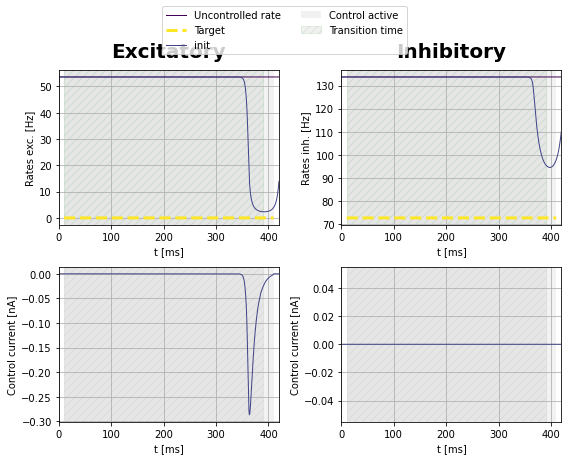

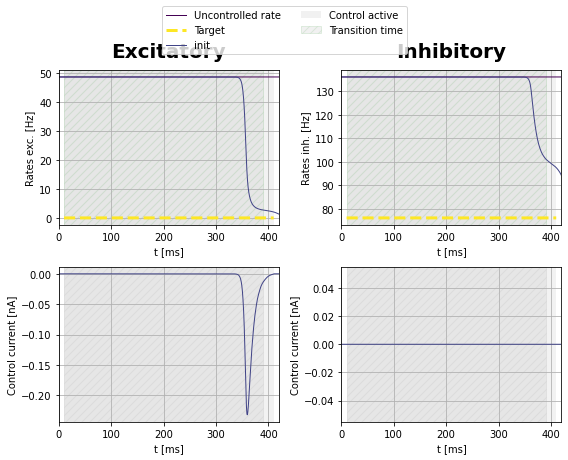

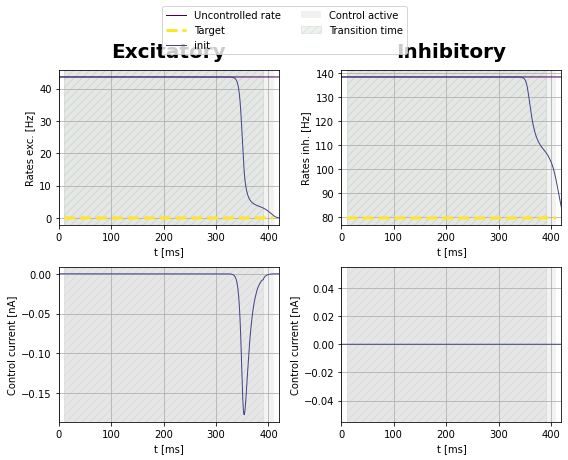

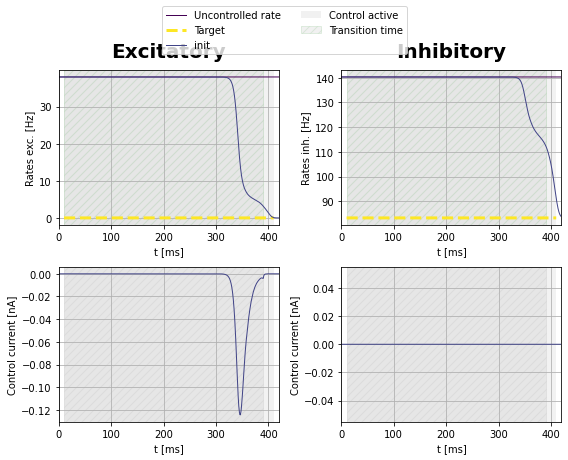

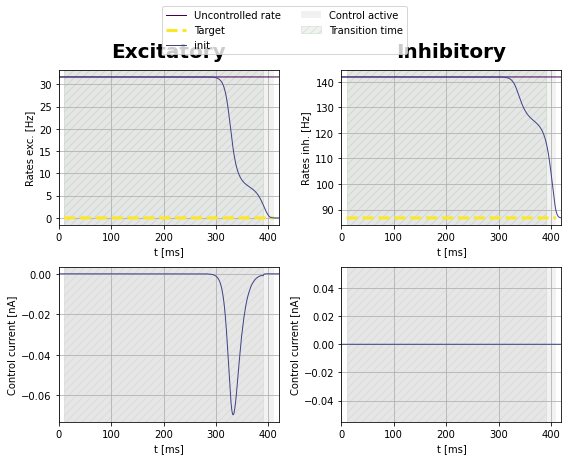

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
found solution for  7
-------  14 0.4250000000000001 0.4500000000000002
found solution for  14
-------  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  333 , total integrated cost =  50.48293710789131
Improved over  333  iterations in  21.968455515801907  seconds by  99.8279765589013  percent.
Problem in initial value trasfer:  Vmean_exc -63.015773738457796 -63.017370610079375
weight =  6050.842271509358
set cost params:  1.0 0.0 6050.842271509358
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30309.77413686297
Gradient descend method:  None
RUN  1 , total integrated cost =  29334.69133222992
RUN  2 , total integrated cost =  29333.075815130793
RUN  3 , total integrated cost =  29332.39429323414
RUN  4 , total integrated cost =  29331.645335738012
RUN  5 , total integrated cost =  29331.08784562011
RUN  6 , total integrated cost =  29330.47109127253
RUN  7 , total integrated cost =  29330.012728620055
RUN  8 , total integrated cost =  29329.454063951034
RUN  9 , total integrated cost =  29329.04751993558
RUN  10 , total integrated cost =  29328.541154689097
RUN  11 , total

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  552 , total integrated cost =  26487.218208840404
Improved over  552  iterations in  37.41050827689469  seconds by  12.611627888620731  percent.
Problem in initial value trasfer:  Vmean_exc -56.67648014518806 -56.67935197757527
-------  42 0.4250000000000001 0.5750000000000003
found solution for  42
-------  49 0.4500000000000001 0.6000000000000003
found solution for  49
-------  56 0.4500000000000001 0.6250000000000003
found solution for  56
-------  63 0.4500000000000001 0.6500000000000004
found solution for  63
-------  70 0.4500000000000001 0.6750000000000004
found solution for  70
-------  77 0.4500000000000001 0.7000000000000004
found solution for  77
-------  84 0.4500000000000001 0.7250000000000004
found solution for  84
-------  91 0.4250000000000001 0.7500000000000004
found solution for  91
-------  98 0.6000000000000003 0.7500000000000004
[0, 7, 14, 21, 28, 42, 49, 56, 63, 70, 77, 84, 91] []
closest index  84
set cost params:  1.0 0.0 10

...

Control only changes marginally.
RUN  341 , total integrated cost =  33915.19577677465
Improved over  341  iterations in  22.925622263923287  seconds by  12.491468736378167  percent.
Problem in initial value trasfer:  Vmean_exc -56.693632325964025 -56.69602841590757
-------  105 0.5750000000000002 0.7750000000000005
[0, 7, 14, 21, 28, 42, 49, 56, 63, 70, 77, 84, 91, 112, 119, 126, 133, 140] [84, 112, 119, 126, 133, 77, 91, 70, 63, 140, 56, 49, 42, 28, 21, 14, 7]
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33862.92349447506
Gradient descend method:  None
RUN  1 , total integrated cost =  194.02174588567013
RUN  2 , total integrated cost =  123.26050554568883
RUN  3 , total integrated cost =  66.94283846302652
RUN  4 , total integrated cost =  65.01217026623604
RUN  5 , total integrated cost =  63.96926192179456
RUN  6 , total integrated cost =  63.32020629209459
RUN  7 , total integrated co

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  253 , total integrated cost =  53.901614422428395
Improved over  253  iterations in  17.063085608184338  seconds by  99.84082409650418  percent.
Problem in initial value trasfer:  Vmean_exc -64.45195201373548 -64.46426827310724
weight =  6287.576161033916
set cost params:  1.0 0.0 6287.576161033916
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33523.09838152764
Gradient descend method:  None
RUN  1 , total integrated cost =  32388.255710673027
RUN  2 , total integrated cost =  32385.870610522772
RUN  3 , total integrated cost =  32384.912259240296
RUN  4 , total integrated cost =  32383.86997226241
RUN  5 , total integrated cost =  32383.167843003805
RUN  6 , total integrated cost =  32382.400269987895
RUN  7 , total integrated cost =  32381.808790225532
RUN  8 , total integrated cost =  32381.136539290113
RUN  9 , total integrated cost =  32380.637416014306
RUN  10 , total integrated cost =  32380.01875477018
RUN  11 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  163 , total integrated cost =  32326.069513919443
Improved over  163  iterations in  11.21747425198555  seconds by  3.570758448353345  percent.
Problem in initial value trasfer:  Vmean_exc -57.292217556885376 -57.27130929466939
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.8750000000000006
-------  140 0.4500000000000001 0.9000000000000006
------------------------------------------------------------
-------------------- 18
------------------------------------------------------------
found solution:  [0, 7, 14, 21, 28, 42, 49, 56, 63, 70, 77, 84, 91, 112, 119, 126, 133, 140]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.50000000

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6925.121599533168
set cost params:  1.0 0.0 6925.121599533168
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.521978081638
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.52196790264
RUN  2 , total integrated cost =  5901.521963463343
RUN  3 , total integrated cost =  5901.521953190246
RUN  4 , total integrated cost =  5901.521953190228


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  5901.521953190226
RUN  6 , total integrated cost =  5901.521953190226
Control only changes marginally.
RUN  6 , total integrated cost =  5901.521953190226
Improved over  6  iterations in  0.6544989123940468  seconds by  4.2177953218924813e-07  percent.
Problem in initial value trasfer:  Vmean_exc -64.75824073426219 -64.76069172199922
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  5678.1497453075035
set cost params:  1.0 0.0 5678.1497453075035
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13554.27865642952
Gradient descend method:  None
RUN  1 , total integrated cost =  13554.275470150627
RUN  2 , total integrated cost =  13554.275422269457
RUN  3 , total integrated cost =  13554.275403210222
RUN  4 , total integrated cost =  13554.275393593474
RUN  5 , total integrated cost =  13554.275393593472
RUN  6 , total integrated cost =  13554.275393593454


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  13554.275393593454
Control only changes marginally.
RUN  7 , total integrated cost =  13554.275393593454
Improved over  7  iterations in  0.6298548374325037  seconds by  2.4072369683381112e-05  percent.
Problem in initial value trasfer:  Vmean_exc -60.97544652511724 -60.99427688808444
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  6315.560019561642
set cost params:  1.0 0.0 6315.560019561642
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8794.637496404697
Gradient descend method:  None
RUN  1 , total integrated cost =  8794.637245945443
RUN  2 , total integrated cost =  8794.637233804246
RUN  3 , total integrated cost =  8794.637233604093


...

39193.338942079354
Control only changes marginally.
RUN  6 , total integrated cost =  39193.338942079354
Improved over  6  iterations in  0.5780998319387436  seconds by  4.591748496807213e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.701047442708486 -56.70092112862056
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
[[True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, T

ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  30526.16015910002
Control only changes marginally.
RUN  4 , total integrated cost =  30526.16015910002
Improved over  4  iterations in  0.4443551991134882  seconds by  0.00023980673850587664  percent.
Problem in initial value trasfer:  Vmean_exc -56.70445803082611 -56.704463108198794
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
no convergence
weight =  9024.662017838127
set cost params:  1.0 0.0 9024.662017838127


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  39194.92136282295
RUN  5 , total integrated cost =  39194.92136282295
Control only changes marginally.
RUN  5 , total integrated cost =  39194.92136282295
Improved over  5  iterations in  0.5588447488844395  seconds by  3.9179800893407446e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70102487924391 -56.70089891747761
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10.654017803074506
Gradient descend method:  None
RUN  1 , total integrated cost =  8.653811422855172
RUN  2 , total integrated cost =  8.653661183756306
RUN  3 , total integrated cost =  8.653656948873179
RUN  4 , total integrated cost =  8.653656256179726
RUN  5 , total integrated cost =  8.653656052384205
RUN  6 , total integrated cost =  8.653655332714948
RUN  7 , total integrated cost =  8.653578781770644
RUN  8 , total integrated cost =  8.653390969991579
RUN  9 , total integrated cost =  8.653387333329043
RUN  10 , total integrated cost =  8.65338639855489
RUN  11 , total integrated cost =  8.653386249454952
RUN  12 , total integrated cost =  8.653385864269948
RUN  13 , total integrated cost =  8.653324913366836
RUN  14 , total integrated cost =  8.653153725503579
RUN  15 , total integrated cost =  8.653148640511406
RUN  16 , tot

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  37 , total integrated cost =  8.652328928913407
Improved over  37  iterations in  11.624405501410365  seconds by  18.788112721038047  percent.
Problem in initial value trasfer:  Vmean_exc -62.7831242740043 -62.781910234807086
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  86.20715483316295
Gradient descend method:  HS
RUN  1 , total integrated cost =  85.58551395628231
RUN  2 , total integrated cost =  85.55853800243644
RUN  3 , total integrated cost =  85.55637388424789
RUN  4 , total integrated cost =  85.55637388424772
RUN  5 , total integrated cost =  85.55637121723596
RUN  6 , total integrated cost =  85.55234350350811
RUN  7 , total integrated cost =  85.55132055656952
RUN  8 , total integrated cost =  85.55117004373658
RUN  9 , total integrated cost =  85.5511596980961
RUN  10 , total integrated cost =  85.55115967912852
RUN  11 , total integrated cost =  85.5511596564834

ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  85.55115965546699
Control only changes marginally.
RUN  16 , total integrated cost =  85.55115965546699
Improved over  16  iterations in  5.190126555040479  seconds by  0.7609521262655079  percent.
Problem in initial value trasfer:  Vmean_exc -64.38003970248732 -64.3697130111497
weight =  6898.271153083898
set cost params:  1.0 0.0 6898.271153083898
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5881.257206947956
Gradient descend method:  None
RUN  1 , total integrated cost =  5876.840196442914
RUN  2 , total integrated cost =  5876.835251862205
RUN  3 , total integrated cost =  5876.835227888008
RUN  4 , total integrated cost =  5876.835227520552
RUN  5 , total integrated cost =  5876.835227494722
RUN  6 , total integrated cost =  5876.835227492384
RUN  7 , total integrated cost =  5876.835227492182
RUN  8 , total integrated cost =  5876.8352274921535
RUN  9 , total integrated cost =  5876.835227492153


...

RUN  15 , total integrated cost =  15.549621034519534
Control only changes marginally.
RUN  15 , total integrated cost =  15.549621034519534
Improved over  15  iterations in  4.223548483103514  seconds by  51.302456727568824  percent.
Problem in initial value trasfer:  Vmean_exc -73.58879975622494 -73.6246305216983
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  155.2814775314682
Gradient descend method:  HS
RUN  1 , total integrated cost =  154.9488225916994
RUN  2 , total integrated cost =  154.86886233706835
RUN  3 , total integrated cost =  154.80482120859364
RUN  4 , total integrated cost =  154.7498837173857
RUN  5 , total integrated cost =  154.6968347153203
RUN  6 , total integrated cost =  154.67094629855
RUN  7 , total integrated cost =  154.40829830155013
RUN  8 , total integrated cost =  154.40672024966494
RUN  9 , total integrated cost =  154.3837721494014
RUN  10 , total integrated cost =  154.351046410

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  47 , total integrated cost =  153.82423283819261
Improved over  47  iterations in  13.944552298635244  seconds by  0.938453649747288  percent.
Problem in initial value trasfer:  Vmean_exc -72.90498230300093 -72.94403952113373
weight =  6512.907681322392
set cost params:  1.0 0.0 6512.907681322392
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10011.802621974104
Gradient descend method:  None
RUN  1 , total integrated cost =  9989.79547122152
RUN  2 , total integrated cost =  9989.736470438183
RUN  3 , total integrated cost =  9989.736440418263
RUN  4 , total integrated cost =  9989.736439814664
RUN  5 , total integrated cost =  9989.73643979262
RUN  6 , total integrated cost =  9989.736439792614
RUN  7 , total integrated cost =  9989.736439792612


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  9989.736439792612
Control only changes marginally.
RUN  8 , total integrated cost =  9989.736439792612
Improved over  8  iterations in  2.7109453678131104  seconds by  0.22040169003193455  percent.
Problem in initial value trasfer:  Vmean_exc -68.94303163910669 -68.99986918058326


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


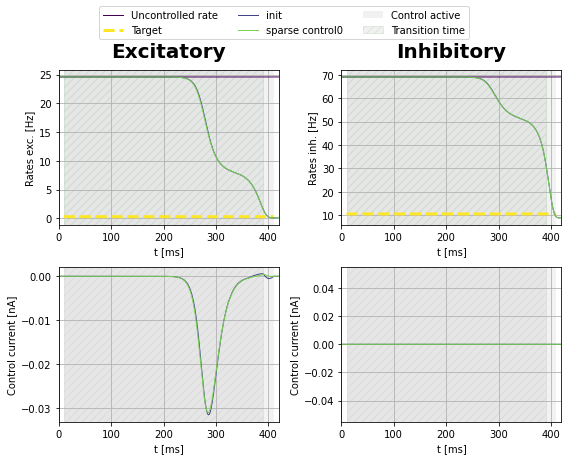

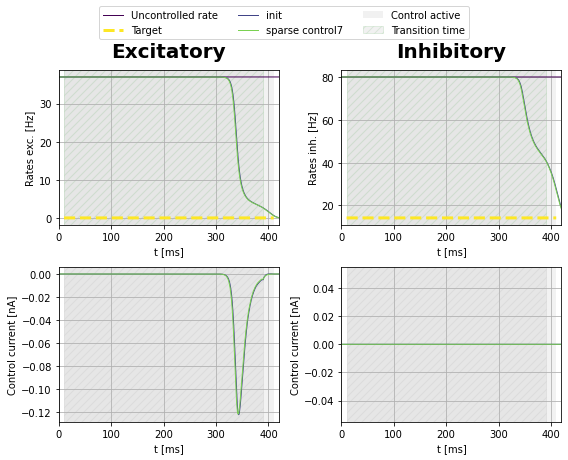

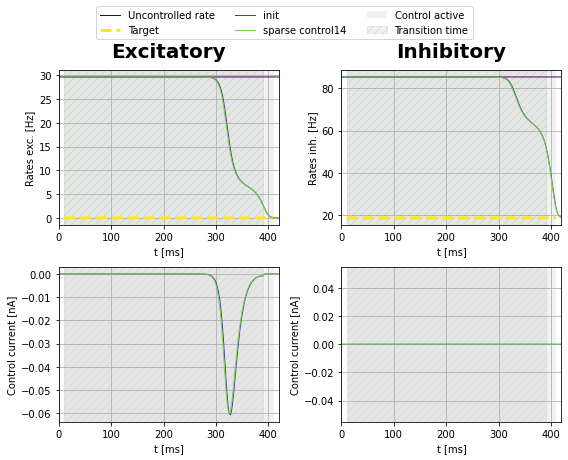

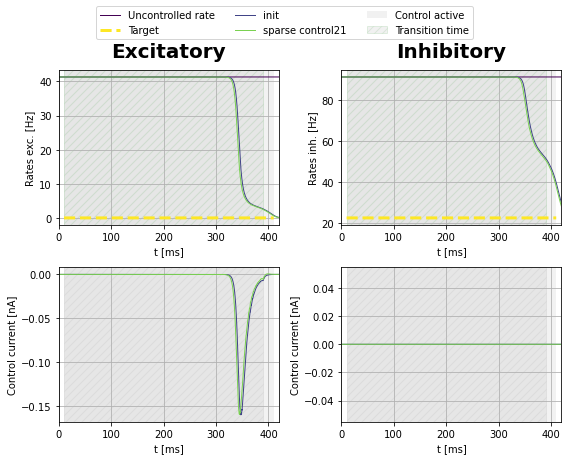

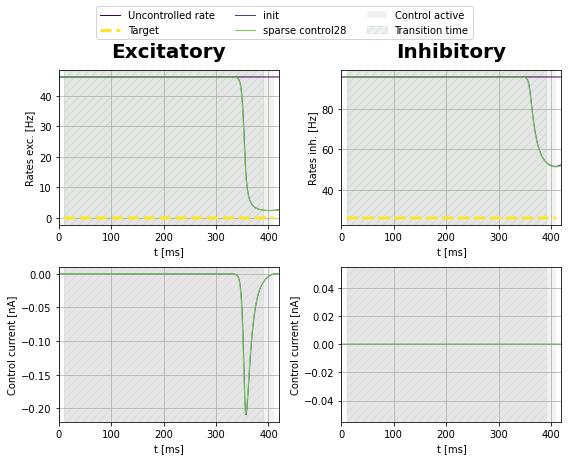

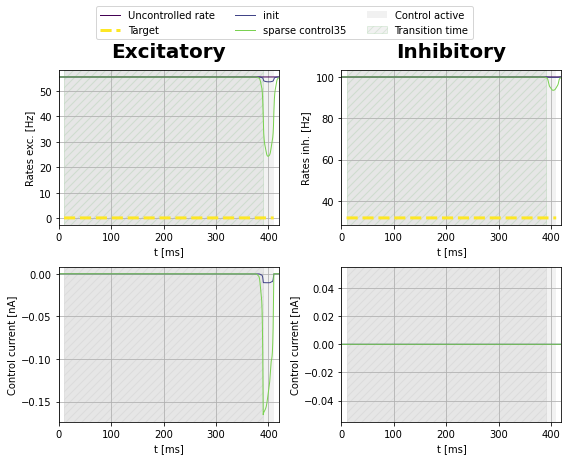

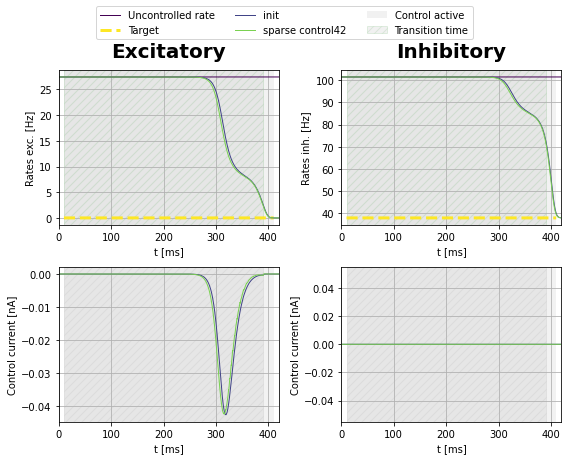

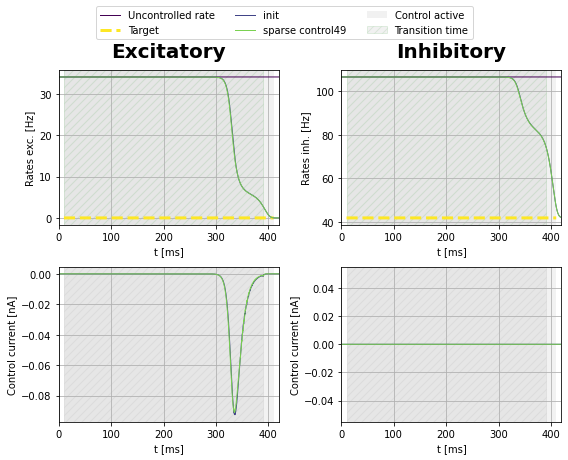

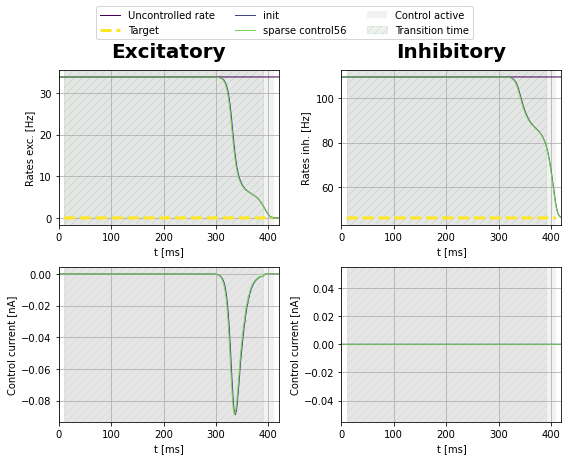

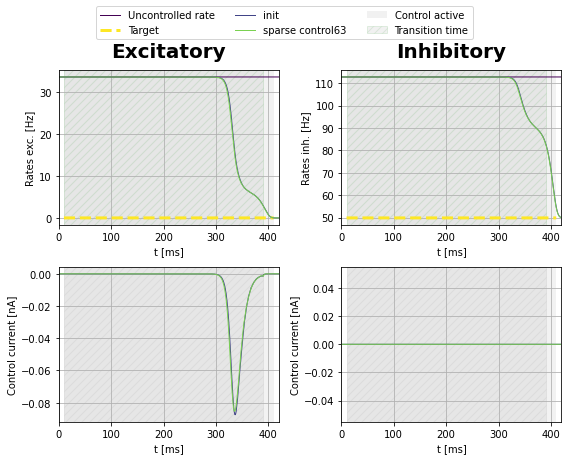

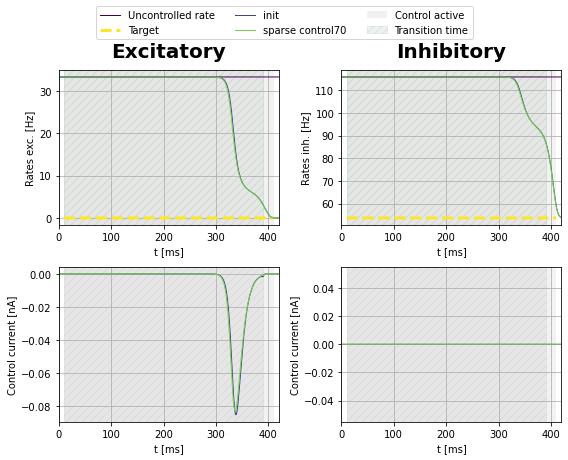

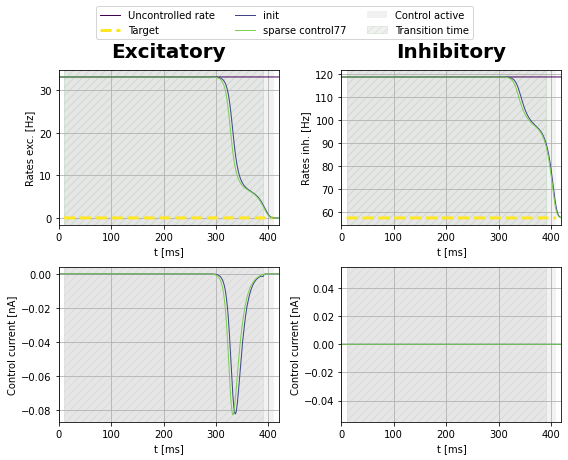

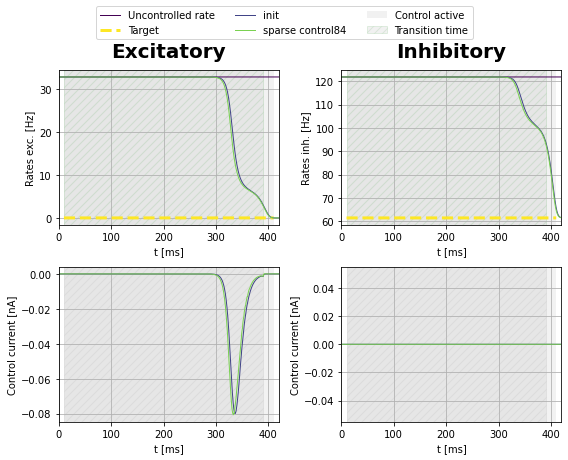

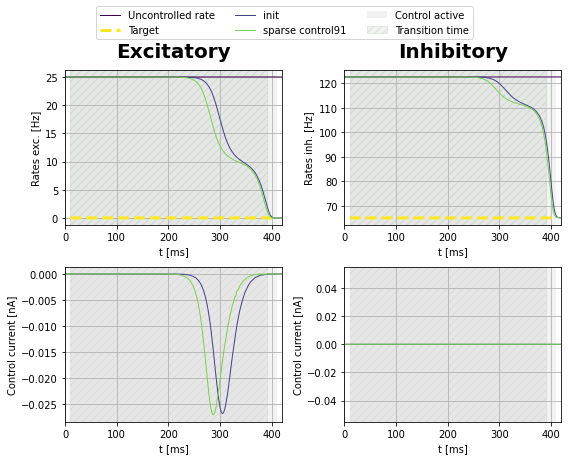

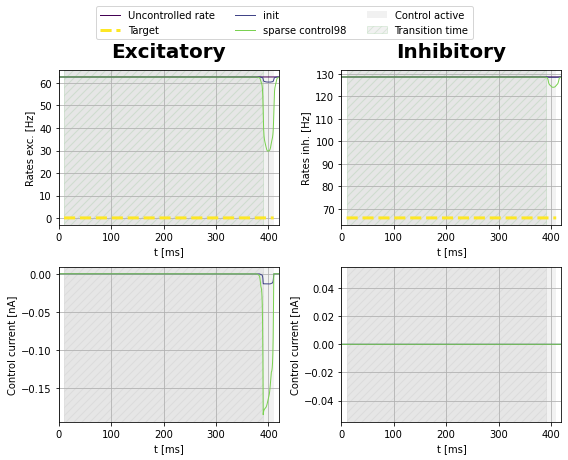

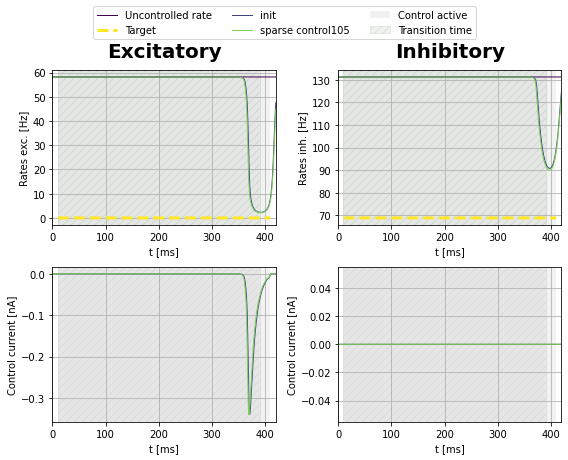

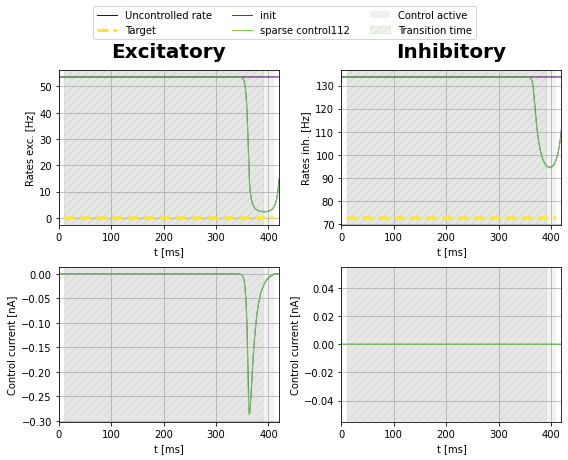

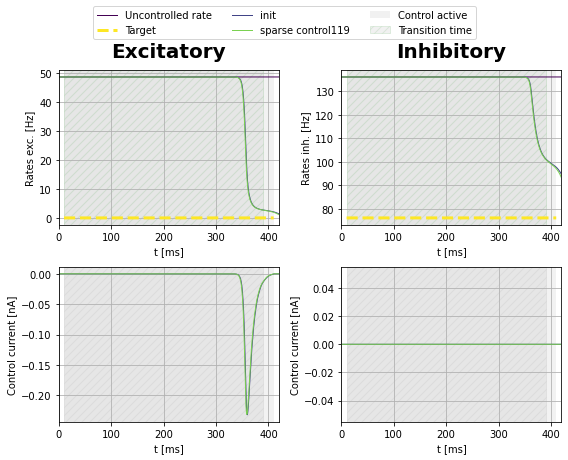

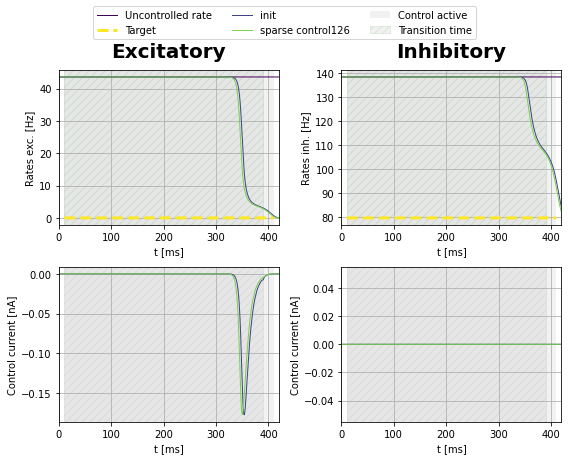

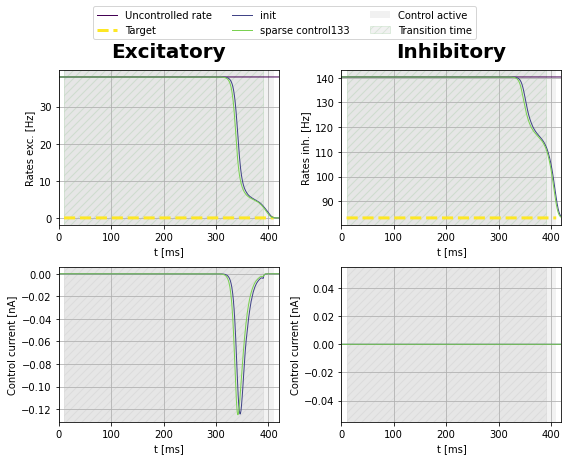

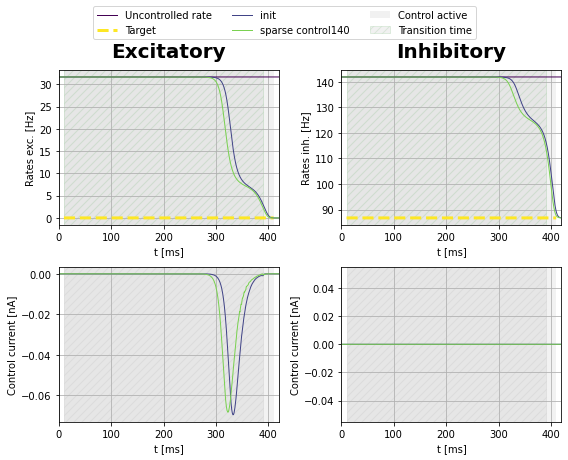

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6927.286870973022
set cost params:  1.0 0.0 6927.286870973022
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.545906506259
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.545902885933
RUN  2 , total integrated cost =  5901.545902885929


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  5901.545902885929
Control only changes marginally.
RUN  3 , total integrated cost =  5901.545902885929
Improved over  3  iterations in  1.303693976253271  seconds by  6.134544605629344e-08  percent.
Problem in initial value trasfer:  Vmean_exc -64.73588616518836 -64.73817786294123
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  5679.939352451487
set cost params:  1.0 0.0 5679.939352451487
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13554.530395056257
Gradient descend method:  None
RUN  1 , total integrated cost =  13554.529034138512
RUN  2 , total integrated cost =  13554.52902079012
RUN  3 , total integrated cost =  13554.529020625343
RUN  4 , total integrated cost =  13554.529020625332
RUN  5 , total integrated cost =  13554.52902062533


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  13554.52902062533
Control only changes marginally.
RUN  6 , total integrated cost =  13554.52902062533
Improved over  6  iterations in  2.345610184594989  seconds by  1.0140011397652415e-05  percent.
Problem in initial value trasfer:  Vmean_exc -61.12712052853749 -61.14674848877986
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  6319.929312259076
set cost params:  1.0 0.0 6319.929312259076
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8794.709561313051
Gradient descend method:  None
RUN  1 , total integrated cost =  8794.709283576716


...

RUN  4 , total integrated cost =  39213.955570609105
Control only changes marginally.
RUN  4 , total integrated cost =  39213.955570609105
Improved over  4  iterations in  1.6684578843414783  seconds by  1.2250859811047121e-06  percent.
Problem in initial value trasfer:  Vmean_exc -56.700517852542596 -56.70044122813393
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 69
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True]

ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  39214.026894880226
Control only changes marginally.
RUN  3 , total integrated cost =  39214.026894880226
Improved over  3  iterations in  1.1755564864724874  seconds by  0.00013716695718812844  percent.
Problem in initial value trasfer:  Vmean_exc -56.700383194417796 -56.70032085809077
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 70
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True]

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  39214.12595254047
Control only changes marginally.
RUN  1 , total integrated cost =  39214.12595254047
Improved over  1  iterations in  0.47934148646891117  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700383194417796 -56.70032085809077
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 71
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [Tru

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.9077589814590157
Gradient descend method:  None
RUN  1 , total integrated cost =  0.8854851039347866
RUN  2 , total integrated cost =  0.885208340692975
RUN  3 , total integrated cost =  0.8848366562278741
RUN  4 , total integrated cost =  0.8845494031160078
RUN  5 , total integrated cost =  0.8840841693232586
RUN  6 , total integrated cost =  0.8836757969443175
RUN  7 , total integrated cost =  0.8829701317523526
RUN  8 , total integrated cost =  0.8822699157795277
RUN  9 , total integrated cost =  0.8800750855423554
RUN  10 , total integrated cost =  0.877557939656361
RUN  11 , total integrated cost =  0.8771056332206226
RUN  12 , total integrated cost =  0.8766414372855531
RUN  13 , total integrated cost =  0.8758873667709237
RUN  14 , total integrated cost =  0.8751092299242276
RUN  15 , total integrated cost =  0.8742084110043785


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  372 , total integrated cost =  0.8674324817931698
Improved over  372  iterations in  23.67149261198938  seconds by  70.16835001373046  percent.
Problem in initial value trasfer:  Vmean_exc -62.967498264869526 -62.9678327745968
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30.553485677760005
Gradient descend method:  None
RUN  1 , total integrated cost =  2.4535260023012353
RUN  2 , total integrated cost =  2.453321390914586
RUN  3 , total integrated cost =  2.450323068452735
RUN  4 , total integrated cost =  2.4484679596116723
RUN  5 , total integrated cost =  2.448441066716788
RUN  6 , total integrated cost =  2.4483314420041906
RUN  7 , total integrated cost =  2.448276837452443
RUN  8 , total integrated cost =  2.446949278330282
RUN  9 , total integrated cost =  2.446059428967964
RUN  10 , total integrated cost =  2.446054900107965
RUN  11 ,

ERROR:root:Problem in initial value trasfer


RUN  90 , total integrated cost =  2.4396664425341954
Control only changes marginally.
RUN  90 , total integrated cost =  2.4396664425341954
Improved over  90  iterations in  5.982958752661943  seconds by  92.01509618815756  percent.
Problem in initial value trasfer:  Vmean_exc -63.918386392265376 -63.917602426840645
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13.866358306556867
Gradient descend method:  None
RUN  1 , total integrated cost =  1.411003691129674
RUN  2 , total integrated cost =  1.4109536708561035
RUN  3 , total integrated cost =  1.4109534813724425
RUN  4 , total integrated cost =  1.4109534088371076
RUN  5 , total integrated cost =  1.4109525196881214
RUN  6 , total integrated cost =  1.4109409189373803
RUN  7 , total integrated cost =  1.410938463150777
RUN  8 , total integrated cost =  1.4109382555163847
RUN  9 , total integrated cost =  1.4109381904568628
RUN 

...

Control only changes marginally.
RUN  73 , total integrated cost =  3.1842500166616503
Improved over  73  iterations in  4.632345410063863  seconds by  91.32152844662266  percent.
Problem in initial value trasfer:  Vmean_exc -70.88277336028015 -70.90649368475509
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23.705072124347755
Gradient descend method:  None
RUN  1 , total integrated cost =  2.398809223735839
RUN  2 , total integrated cost =  2.398744296570541
RUN  3 , total integrated cost =  2.398743483402875
RUN  4 , total integrated cost =  2.398743454333806
RUN  5 , total integrated cost =  2.398743441227537
RUN  6 , total integrated cost =  2.3987434392226623
RUN  7 , total integrated cost =  2.39874343922266


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  2.3987434392226596
RUN  9 , total integrated cost =  2.3987434392226596
Control only changes marginally.
RUN  9 , total integrated cost =  2.3987434392226596
Improved over  9  iterations in  0.7451416756957769  seconds by  89.88088529475984  percent.
Problem in initial value trasfer:  Vmean_exc -72.66518262775857 -72.69298020467791
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8.623920310376105
Gradient descend method:  None
RUN  1 , total integrated cost =  1.543019268785855
RUN  2 , total integrated cost =  1.5430031357499419
RUN  3 , total integrated cost =  1.5430031356545684
RUN  4 , total integrated cost =  1.5430031356476337
RUN  5 , total integrated cost =  1.5430031356471763
RUN  6 , total integrated cost =  1.5430031356471414
RUN  7 , total integrated cost =  1.543003135647139


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  1.5430031356471385
RUN  9 , total integrated cost =  1.543003135647138
RUN  10 , total integrated cost =  1.543003135647138
Control only changes marginally.
RUN  10 , total integrated cost =  1.543003135647138
Improved over  10  iterations in  0.7465653866529465  seconds by  82.10786881007434  percent.
Problem in initial value trasfer:  Vmean_exc -74.64191912944648 -74.6727994272611


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.8674324817931698
Gradient descend method:  None
RUN  1 , total integrated cost =  0.8674324817931698
Control only changes marginally.
RUN  1 , total integrated cost =  0.8674324817931698
Improved over  1  iterations in  0.15829088725149632  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -62.967498264869526 -62.9678327745968
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.4396664425341954
Control only changes marginally.
RUN  1 , total integrated cost =  2.4396664425341954
Improved over  1  iterations in  0.15885222144424915  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -63.918386392265376 -63.917602426840645
-------  14 0.4250000000000001 0.4500000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.4084896266113947
Gradient descend method:  None
RUN  1 , total integrated cost =  1.4084896266113947
Control only changes marginally.
RUN  1 , total integrated cost =  1.4084896266113947
Improved over  1  iterations in  0.15785492025315762  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -69.2901430068661 -69.30017958552034
-------  21 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.98513991

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  5.443176453656582
Control only changes marginally.
RUN  1 , total integrated cost =  5.443176453656582
Improved over  1  iterations in  0.16103194653987885  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.87433174517197 -65.8823696976242
-------  112 0.5500000000000003 0.8000000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4.68487173454284
Gradient descend method:  None
RUN  1 , total integrated cost =  4.68487173454284
Control only changes marginally.
RUN  1 , total integrated cost =  4.68487173454284
Improved over  1  iterations in  0.1601798441261053  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -67.44955748249691 -67.46384090104026
-------  119 0.5250000000000001 0.8250000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.928975585737283
Gr

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.928975585737283
Control only changes marginally.
RUN  1 , total integrated cost =  3.928975585737283
Improved over  1  iterations in  0.15972520597279072  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -69.17760394509195 -69.19672440563714
-------  126 0.5000000000000002 0.8500000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.1842500166616503
Gradient descend method:  None
RUN  1 , total integrated cost =  3.1842500166616503
Control only changes marginally.
RUN  1 , total integrated cost =  3.1842500166616503
Improved over  1  iterations in  0.1575434822589159  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -70.88277336028015 -70.90649368475509
-------  133 0.47500000000000014 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.3987434392

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.3987434392226596
Control only changes marginally.
RUN  1 , total integrated cost =  2.3987434392226596
Improved over  1  iterations in  0.15884962491691113  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -72.66518262775857 -72.69298020467791
-------  140 0.4500000000000001 0.9000000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.543003135647138
Gradient descend method:  None
RUN  1 , total integrated cost =  1.543003135647138
Control only changes marginally.
RUN  1 , total integrated cost =  1.543003135647138
Improved over  1  iterations in  0.15796305984258652  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -74.64191912944648 -74.6727994272611
--------------- 21
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [F

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
